In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
housing = pd.read_csv(r"C:\Users\Prakash\Desktop\Ai_learning_journey\Month2-machine-learning\house-price-prediction\housing.csv")

In [3]:
housing.shape
housing.head()
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

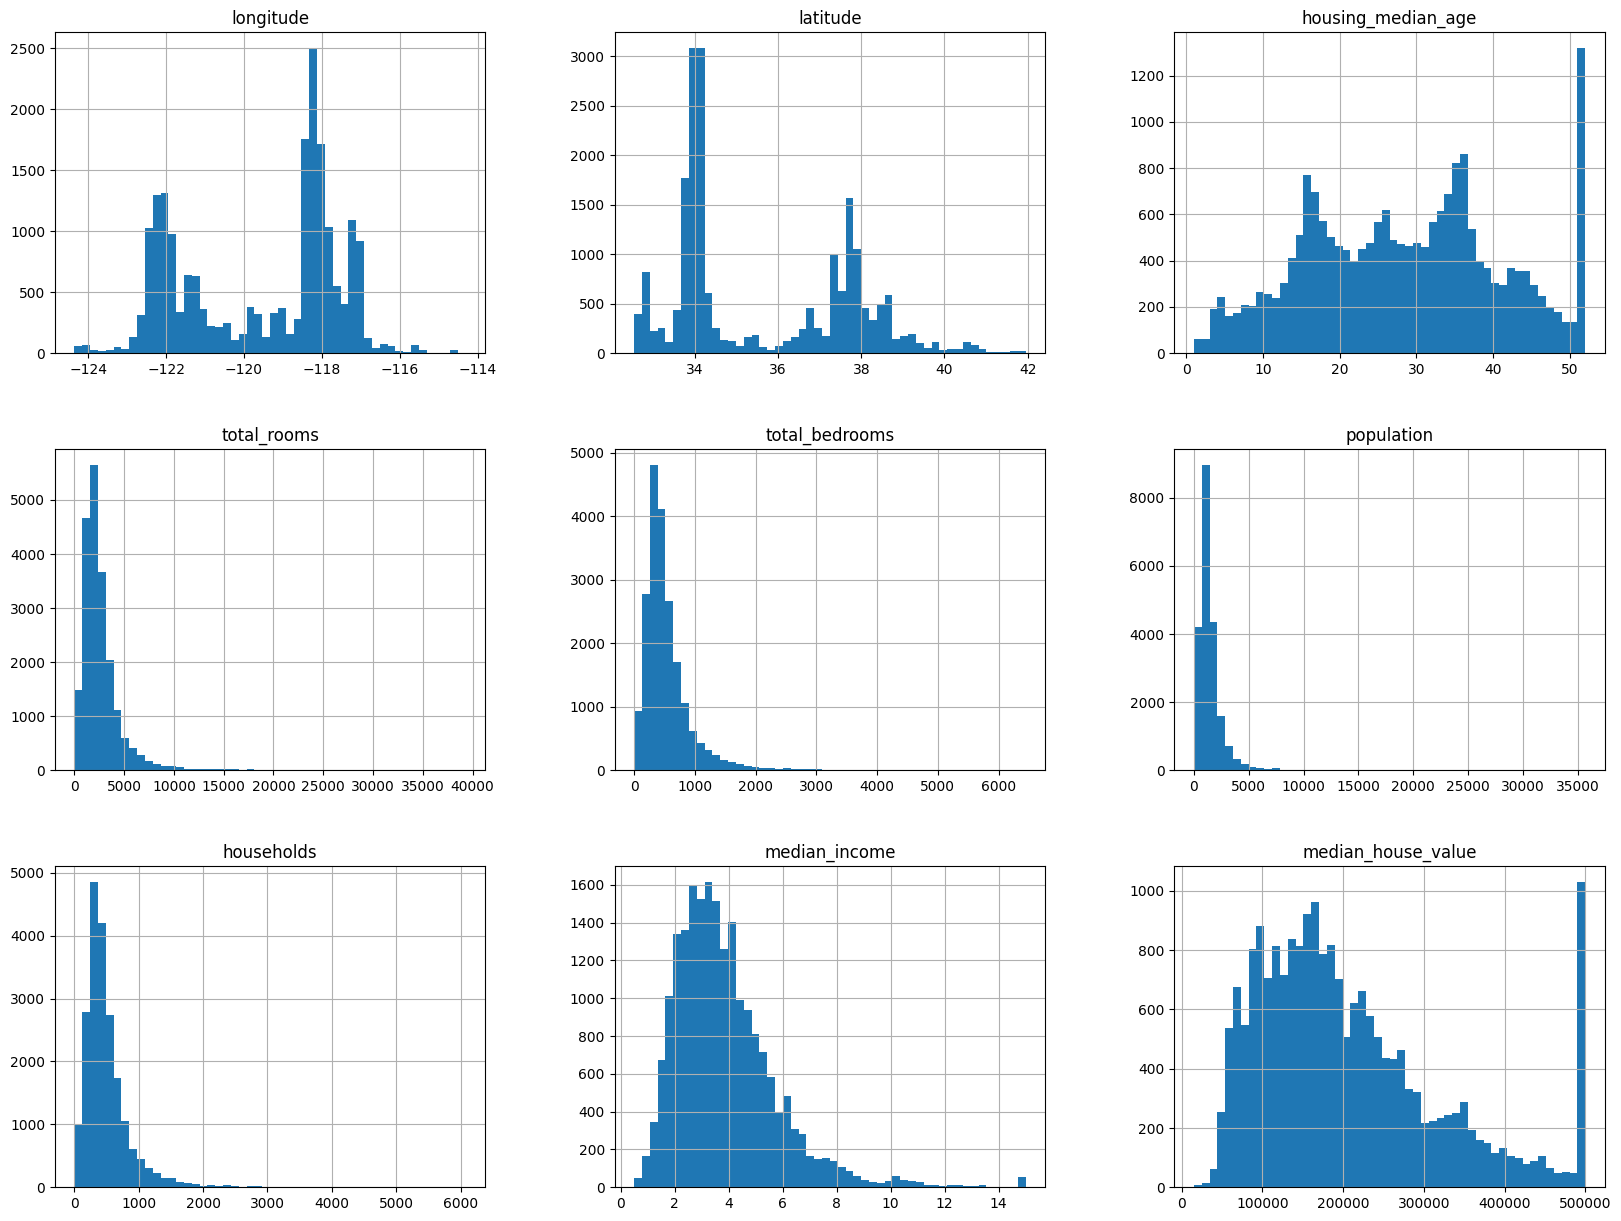

In [6]:
housing.hist(bins = 50,figsize = (20,15))

<Axes: xlabel='longitude', ylabel='latitude'>

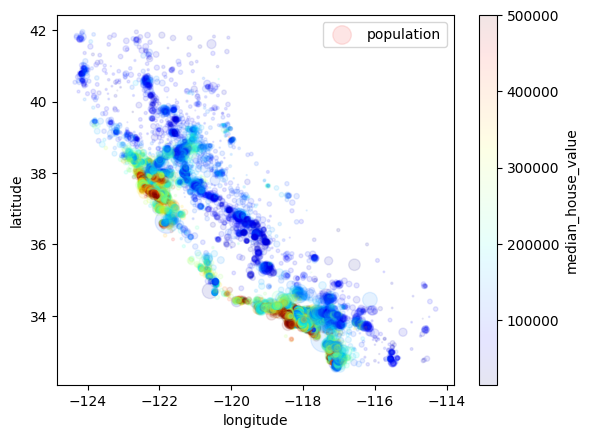

In [7]:
housing.plot(kind="scatter", x = "longitude",y = "latitude",alpha =0.1,s =housing["population"]/100,label = "population",c = "median_house_value",cmap =plt.get_cmap("jet"))

In [8]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [ ]:
#removing the rows with missing values
housing_na = housing.dropna(subset=["total_bedrooms"])
housing_na.shape

(20433, 10)

In [10]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
dummies =pd.get_dummies(housing_na.ocean_proximity)
housing_na_dummies = pd.concat([housing_na,dummies],axis='columns')
housing_na_dummies.head()

housing_clean = housing_na_dummies.drop(['ocean_proximity','ISLAND'],axis='columns')
housing_clean.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [12]:
#creating Features and label datasets
X = housing_clean.drop(columns = ['median_house_value'])
X.head()
y = housing_clean['median_house_value']
y.head()


0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 1984)

In [21]:
from sklearn.linear_model import LinearRegression

OLS = LinearRegression()
OLS.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
#display the intercept and coefficients of the OLS model
print("OLS intercept:",str(OLS.intercept_))
print("OLS coefficients:",str(OLS.coef_))
print("The R-square of the model is:",OLS.score(X_train,y_train))


OLS intercept: -2077866.1072581143
OLS coefficients: [-2.64197489e+04 -2.53760750e+04  1.06443061e+03 -6.14422659e+00
  9.55095351e+01 -3.58495559e+01  4.87620759e+01  3.95243431e+04
 -1.50245450e+05 -1.89412613e+05 -1.53350286e+05 -1.45649963e+05]
The R-square of the model is: 0.6429996299635299


In [23]:
#predicting with OLS

y_pred = OLS.predict(X_test)
performance = pd.DataFrame({'PREDICTIONS': y_pred,'ACTUAL VALUES':y_test})
performance['ERROR'] = performance['ACTUAL VALUES'] - performance['PREDICTIONS']
performance.head()

,PREDICTIONS,ACTUAL VALUES,ERROR
15175,315802.992105,328200.0,12397.007895
15424,236437.353328,156900.0,-79537.353328
16212,157347.789257,87200.0,-70147.789257
15356,173300.104579,141000.0,-32300.104579
1899,83587.988926,100800.0,17212.011074


In [24]:
#preparing the data for plotting

performance.reset_index(drop=True,inplace=True)
performance.reset_index(inplace=True)
performance.head()

,index,PREDICTIONS,ACTUAL VALUES,ERROR
0,0,315802.992105,328200.0,12397.007895
1,1,236437.353328,156900.0,-79537.353328
2,2,157347.789257,87200.0,-70147.789257
3,3,173300.104579,141000.0,-32300.104579
4,4,83587.988926,100800.0,17212.011074


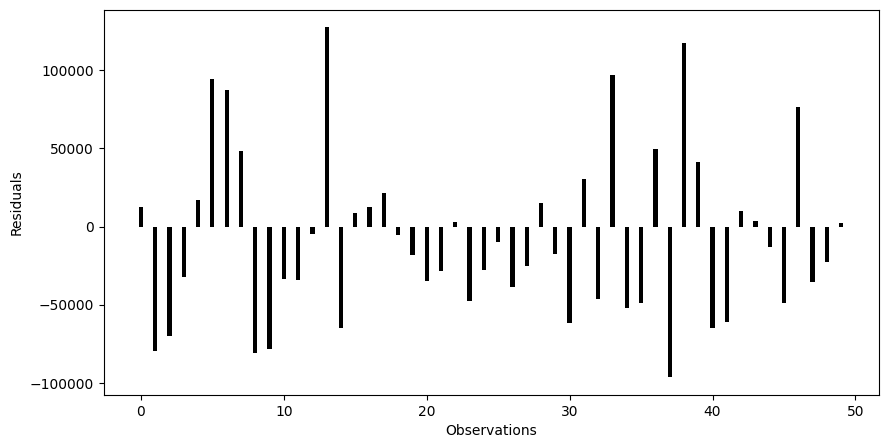

In [25]:
#plot the residuals

fig = plt.figure(figsize=(10,5))
plt.bar('index','ERROR',data = performance[:50],color = 'black',width=0.3)
plt.xlabel("Observations")
plt.ylabel("Residuals")
plt.show()


In [26]:
import statsmodels.api as sm

# 1. Convert boolean columns to integers
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)

# 2. Remove existing const if present
if 'const' in X_train.columns:
    X_train = X_train.drop(columns=['const'])

# 3. Convert everything to float
X_train = X_train.astype(float)

# 4. Add constant
X_train = sm.add_constant(X_train)

# 5. Fit OLS
nicerOLS = sm.OLS(y_train, X_train).fit()
nicerOLS.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     2145.
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        19:15:29   Log-Likelihood:            -1.7961e+05
No. Observations:               14303   AIC:                         3.592e+05
Df Residuals:                   14290   BIC:                         3.593e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.078e+06   1.12e+05    -18.570      0.000    -2.3e+06   -1.86e+06
longitude          -2.642e+04   1222.626    -21.609      0.000   -2.88e+04    -2.4e+04
latitude           -2.538e+04   1204.160    -21.074      0.000   -2.77e+04    -2.3e+04
housing_median_age  1064.4306     52.885     20.127      0.000     960.769    1168.093
total_rooms           -6.1442      0.944     -6.511      0.000      -7.994      -4.295
total_bedrooms        95.5095      7.993     11.949      0.000      79.842     111.177
population           -35.8496      1.247    -28.759      0.000     -38.293     -33.406
households            48.7621      8.610      5.663      0.000      31.885      65.639
median_income       3.952e+04    410.863     96.198      0.000    3.87e+04    4.03e+04
<1H OCEAN          -1.502e+05   3.44e+04     -4.363      0.000   -2.18e+05   -8.27e+04
INLAND             -1.894e+05   3.45e+04     -5.487      0.000   -2.57e+05   -1.22e+05
NEAR BAY           -1.534e+05   3.45e+04     -4.446      0.000   -2.21e+05   -8.57e+04
NEAR OCEAN         -1.456e+05   3.45e+04     -4.227      0.000   -2.13e+05   -7.81e+04
==============================================================================
Omnibus:                     3507.484   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13538.841
Skew:                           1.180   Prob(JB):                         0.00
Kurtosis:                       7.141   Cond. No.                     8.03e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.03e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""